# Application Layer Guide

This notebook demonstrates the Application Layer, which currently implements the **QKD E91 protocol** for Quantum Key Distribution.

## Imports and Setup

In [3]:
import sys
sys.path.append('../')
from quantumnet.topology import Network, Host
from quantumnet.utils import Logger

Logger.get_instance().activate()

2026-02-22 19:28:49,788: Qubit 0 added to memory of Host 0.
2026-02-22 19:28:49,789: Qubit 0 created with initial fidelity 0.24515984462806883 and added to memory of Host 0.
2026-02-22 19:28:49,791: Qubit 1 added to memory of Host 0.
2026-02-22 19:28:49,793: Qubit 1 created with initial fidelity 0.8792534898644772 and added to memory of Host 0.
2026-02-22 19:28:49,794: Qubit 2 added to memory of Host 0.
2026-02-22 19:28:49,796: Qubit 2 created with initial fidelity 0.754312686242211 and added to memory of Host 0.
2026-02-22 19:28:49,797: Qubit 3 added to memory of Host 0.
2026-02-22 19:28:49,799: Qubit 3 created with initial fidelity 0.9156050385654231 and added to memory of Host 0.
2026-02-22 19:28:49,799: Qubit 4 added to memory of Host 0.
2026-02-22 19:28:49,801: Qubit 4 created with initial fidelity 0.49720398378099795 and added to memory of Host 0.
2026-02-22 19:28:49,802: Qubit 5 added to memory of Host 0.
2026-02-22 19:28:49,803: Qubit 5 created with initial fidelity 0.888961117

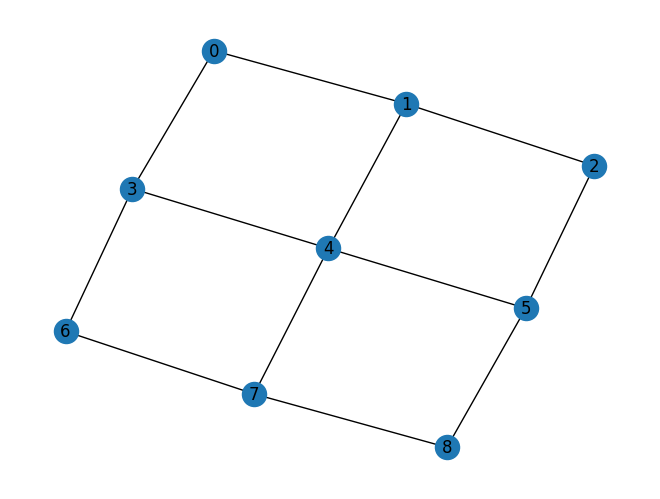

In [4]:
network = Network()
network.set_ready_topology("Grade", 3, 3)
network.draw()

## 1. Running the QKD E91 Protocol

The E91 protocol generates a shared secret key between Alice and Bob. The steps are:
1. Alice generates a random bit key and chooses random measurement bases.
2. Qubits are prepared (X and Hadamard gates applied according to key/bases).
3. Qubits are transmitted to Bob via the transport layer.
4. Bob chooses random bases and measures the received qubits.
5. Alice and Bob share their bases and keep only the bits where bases matched.

Use `application_layer.run_app("QKD_E91", alice_id, bob_id, num_bits)` to execute.

In [5]:
alice_id = 0
bob_id = 8
num_key_bits = 5

shared_key = network.application_layer.run_app("QKD_E91", alice_id, bob_id, num_key_bits)
print(f"\nShared key: {shared_key}")

2026-02-22 19:28:51,257: Starting E91 protocol with 10 qubits.
2026-02-22 19:28:51,258: E91 qubits prepared at timeslot: 0
2026-02-22 19:28:51,260: Qubits prepared with key: [1, 1, 1, 0, 0, 0, 0, 1, 0, 0] and bases: [1, 0, 1, 1, 1, 1, 1, 0, 0, 0]
2026-02-22 19:28:51,262: Attempt 1 of qubit transmission between 0 and 8.
2026-02-22 19:28:51,263: Timeslot 0: Looking for valid route between 0 and 8.
2026-02-22 19:28:51,265: Valid route found: [0, 3, 6, 7, 8]
2026-02-22 19:28:51,266: Qubit teleportation from 0 to 8 on route [0, 3, 6, 7, 8] succeeded with final fidelity 0.24515984462806883.
2026-02-22 19:28:51,267: Timeslot 0: Looking for valid route between 0 and 8.
2026-02-22 19:28:51,268: Valid route found: [0, 3, 6, 7, 8]
2026-02-22 19:28:51,270: Qubit teleportation from 0 to 8 on route [0, 3, 6, 7, 8] succeeded with final fidelity 0.8792534898644772.
2026-02-22 19:28:51,271: Timeslot 0: Looking for valid route between 0 and 8.
2026-02-22 19:28:51,272: Valid route found: [0, 3, 6, 7, 8]



Shared key: [1, 1, 1, 1, 0]


## 2. Inspecting Teleported Qubits

The transport layer records every qubit teleportation performed during the protocol.

In [6]:
teleported = network.transportlayer.get_teleported_qubits()
print(f"Total qubits teleported: {len(teleported)}")
for i, info in enumerate(teleported[:5]):  # show first 5
    print(f"  Qubit {i}: route={info['route']}, F_final={info['F_final']:.4f}")

Total qubits teleported: 12
  Qubit 0: route=[0, 3, 6, 7, 8], F_final=0.2452
  Qubit 1: route=[0, 3, 6, 7, 8], F_final=0.8793
  Qubit 2: route=[0, 3, 6, 7, 8], F_final=0.7543
  Qubit 3: route=[0, 3, 6, 7, 8], F_final=0.9156
  Qubit 4: route=[0, 3, 6, 7, 8], F_final=0.4972


## 3. Metrics

In [7]:
print(f"Timeslot: {network.clock.now}")
print(f"Qubits used (application layer): {network.application_layer.get_used_qubits()}")
print(f"Total used qubits (all layers): {network.get_total_used_qubits()}")
print(f"Total used EPRs (all layers): {network.get_total_used_eprs()}")
print(f"Transport layer avg fidelity: {network.transportlayer.avg_fidelity_on_transportlayer():.6f}")

2026-02-22 19:28:51,398: Qubits used in layer ApplicationLayer: 12
2026-02-22 19:28:51,399: Qubits used in layer PhysicalLayer: 2
2026-02-22 19:28:51,400: Qubits used in layer LinkLayer: 0
2026-02-22 19:28:51,401: Qubits used in layer TransportLayer: 12
2026-02-22 19:28:51,402: Qubits used in layer ApplicationLayer: 12
2026-02-22 19:28:51,402: EPRs used in layer PhysicalLayer: 0
2026-02-22 19:28:51,403: EPRs used in layer LinkLayer: 0
2026-02-22 19:28:51,404: EPRs used in layer NetworkLayer: 0
2026-02-22 19:28:51,406: Fidelity of qubit used from 0 to 8: 0.24515984462806883
2026-02-22 19:28:51,406: Fidelity of qubit used from 0 to 8: 0.8792534898644772
2026-02-22 19:28:51,407: Fidelity of qubit used from 0 to 8: 0.754312686242211
2026-02-22 19:28:51,408: Fidelity of qubit used from 0 to 8: 0.9156050385654231
2026-02-22 19:28:51,409: Fidelity of qubit used from 0 to 8: 0.49720398378099795
2026-02-22 19:28:51,409: Fidelity of qubit used from 0 to 8: 0.8889611170414401
2026-02-22 19:28:51,

Timeslot: 4
Qubits used (application layer): 12
Total used qubits (all layers): 26
Total used EPRs (all layers): 0
Transport layer avg fidelity: 0.587846
